# River Discharge — Classification par Barycentre (agg=4)

Notebook d'exploration de la **classification nearest-barycenter** sur les données de débit de rivière,
avec **agrégation temporelle sur 4 jours** (T=91 timesteps, ~200 valeurs/timestep).

**Plan du notebook :**
1. Chargement des données et exploration
2. Estimation des paramètres exponentiels (β)
3. **eucl_params/bary** — barycentre en espace Euclidien (sur les β estimés)
4. **wasps/bary** — barycentre avec coût Wasserstein W₂² (avec contrainte positivité)
5. **eucl_raw/bary** — barycentre sur les données brutes
6. Comparaison des 3 méthodes
7. Exploration interactive (γ, lr, n_steps)

> Exécuter depuis la **racine du dépôt** avec le kernel `.venv`.

In [1]:
import sys
from pathlib import Path

_SRC = Path("../src").resolve()
sys.path.insert(0, str(_SRC))

import jax
jax.config.update("jax_enable_x64", True)
import time

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import confusion_matrix, f1_score, ConfusionMatrixDisplay, accuracy_score

import distributions
from data.preprocess import clean_time_series
from data.river_loader import load_river_classification
from costs import SqEuclidean, WaSPS
from softdtw import SoftDTW
from barycenter import fit_barycenter
from classification.barycenter_clf import fit_barycenters, predict

print(f"JAX devices : {jax.devices()}")
print("Imports OK")

JAX devices : [CpuDevice(id=0)]
Imports OK


---
## 1. Chargement et exploration des données

In [104]:
# ── Configuration ─────────────────────────────────────────────────────────────
DATA_DIR        = "../data/river_new/output_4"
AGGREGATE_DAYS  = 5       # 4 jours → T=91, ~200 valeurs valides/timestep
SAMPLES_PER_STEP = 200    # sous-échantillonnage après agrégation (≤ ~348 valides)
TEST_SIZE       = 0.25
SEED            = 42
# ─────────────────────────────────────────────────────────────────────────────

data = load_river_classification(
    DATA_DIR,
    mode="balanced",
    test_size=TEST_SIZE,
    aggregate_days=AGGREGATE_DAYS,
    # samples_per_step=SAMPLES_PER_STEP,
    seed=SEED,
)

X_train      = data["X_train"]      # list[N_train] de (T, 200) arrays
X_test       = data["X_test"]
y_train      = data["y_train"]      # (N_train,) int
y_test       = data["y_test"]
class_names  = data["class_names"]  # {int: str}

T, D = X_train[0].shape
classes = sorted(set(y_train.tolist()))

print(f"Train : {len(X_train)} séries   Test : {len(X_test)} séries")
print(f"Forme par série : T={T} timesteps (4-jours), {D} valeurs/timestep")
print(f"Classes : {[class_names.get(c, c) for c in classes]}")
print()
A,B = [],[]

#keep 50 samples per classes:
for cls in classes:
    X_train_cls = [s for i, s in enumerate(X_train) if (y_train[i] in classes) and (y_train[i] == cls)]
    X_train_cls = X_train_cls[:]
    y_train_cls = [cls] * len(X_train_cls)
    A.extend(X_train_cls)
    B.extend(y_train_cls)
X_train = A
y_train = np.array(B)

# #keep only PC classes
# for cls in classes:
#     if cls==3:
#         X_train_cls = [s for i, s in enumerate(X_train) if (y_train[i] in classes) and (y_train[i] == cls)]
#         X_train_cls = X_train_cls[:4]
#         y_train_cls = [cls] * len(X_train_cls)
#         A.extend(X_train_cls)
#         B.extend(y_train_cls)
# X_train = A
# y_train = np.array(B)

# #downsample the number of samples and not timestep
# X_train = [s[:,::10] for s in X_train]
# X_test  = [s[:,::10] for s in X_test]


for cls in classes:
    n_tr = (y_train == cls).sum()
    n_te = (y_test  == cls).sum()
    print(f"  {class_names.get(cls, cls):4s} (label={cls}) : train={n_tr}  test={n_te}")



Train : 450 séries   Test : 150 séries
Forme par série : T=73 timesteps (4-jours), 320 valeurs/timestep
Classes : ['NG', 'NP', 'NV', 'PC', 'PM', 'PN']

  NG   (label=0) : train=75  test=25
  NP   (label=1) : train=75  test=25
  NV   (label=2) : train=75  test=25
  PC   (label=3) : train=75  test=25
  PM   (label=4) : train=75  test=25
  PN   (label=5) : train=75  test=25


/tmp/ipykernel_97778/2349129897.py:8: RuntimeWarning: Mean of empty slice
  np.nanmean(X_train[i], axis=1)  # (T,)


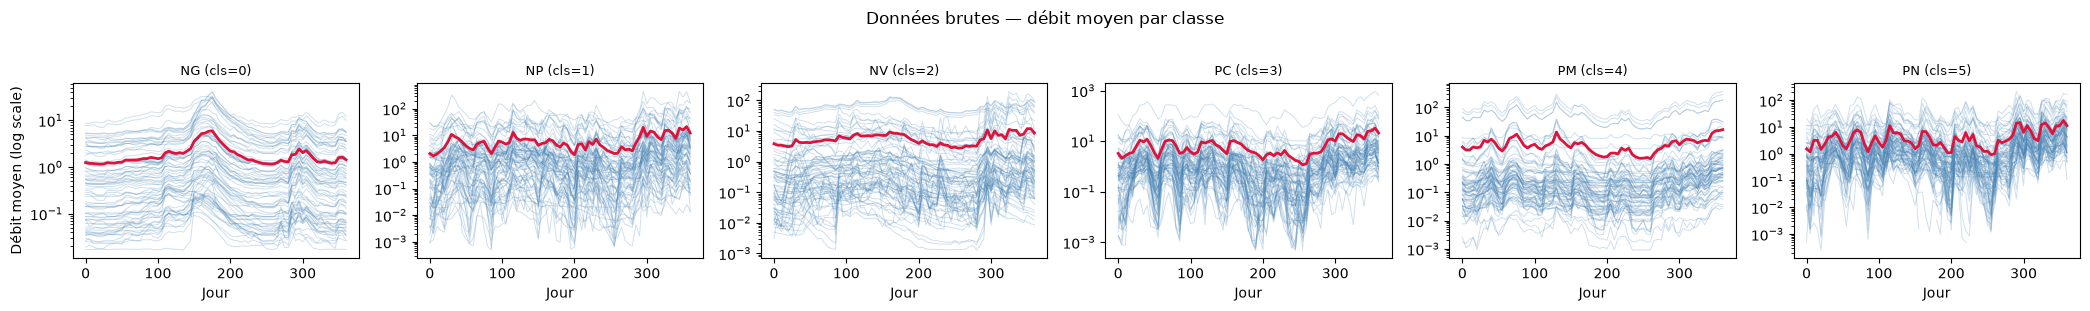

In [105]:
# Visualisation des données brutes — débit moyen par classe sur le temps
fig, axes = plt.subplots(1, len(classes), figsize=(3.5 * len(classes), 3), sharey=False)

for ax, cls in zip(axes, classes):
    idx = np.where(y_train == cls)[0]
    # Débit moyen par timestep par série
    cls_mean = np.array([
        np.nanmean(X_train[i], axis=1)  # (T,)
        for i in idx
    ])  # (N_cls, T)
    t = np.arange(T) * AGGREGATE_DAYS  # axe en jours originaux
    for row in cls_mean:
        ax.semilogy(t, row, color="steelblue", alpha=0.25, linewidth=0.7)
    ax.semilogy(t, np.nanmean(cls_mean, 0), color="crimson", linewidth=2, label="moyenne")
    ax.set_title(f"{class_names.get(cls, cls)} (cls={cls})", fontsize=9)
    ax.set_xlabel("Jour")

axes[0].set_ylabel("Débit moyen (log scale)")
plt.suptitle("Données brutes — débit moyen par classe", y=1.02)
plt.tight_layout()
plt.show()

---
## 2. Estimation des paramètres exponentiels β

`β = 1/E[X]` : taux de la loi exponentielle. Grand β = débit faible (station sèche).  
`clean_time_series` filtre les valeurs NaN et ≤0 par timestep avant MLE.

In [106]:
print("Estimation MLE des paramètres exponentiels β ...")
dist = distributions.get("exponential")


train_params = [dist.fit_time_series(clean_time_series(s, threshold=-1.0), dtype=np.float64, method="log_cumulant") for s in X_train]
test_params  = [dist.fit_time_series(clean_time_series(s, threshold=-1.0), dtype=np.float64, method="log_cumulant") for s in X_test]

print(f"Forme d'un array de params : {train_params[0].shape}  (T, 1=taux β)")

# Statistiques globales
all_b = np.concatenate([p[~np.isnan(p)] for p in train_params])
total_nan = sum(np.isnan(p).sum() for p in train_params)
total_val = sum(p.size for p in train_params)
print(f"β : min={all_b.min():.4g}  median={np.median(all_b):.3g}  max={all_b.max():.4g}")
print(f"NaN : {total_nan}/{total_val} ({100*total_nan/total_val:.2f}%) — corrigés par NaN-fill dans fit_barycenter")

#drop NaN values from train_params and test_params 
# train_params = [p[~np.isnan(p)] for p in train_params]
# test_params  = [p[~np.isnan(p)] for p in test_params]
# train_params = [np.nan_to_num(p, nan=1) for p in train_params]
# test_params  = [np.nan_to_num(p, nan=1) for p in test_params]

Estimation MLE des paramètres exponentiels β ...
Forme d'un array de params : (73, 1)  (T, 1=taux β)
β : min=0.003577  median=6.68  max=1156
NaN : 21/32850 (0.06%) — corrigés par NaN-fill dans fit_barycenter


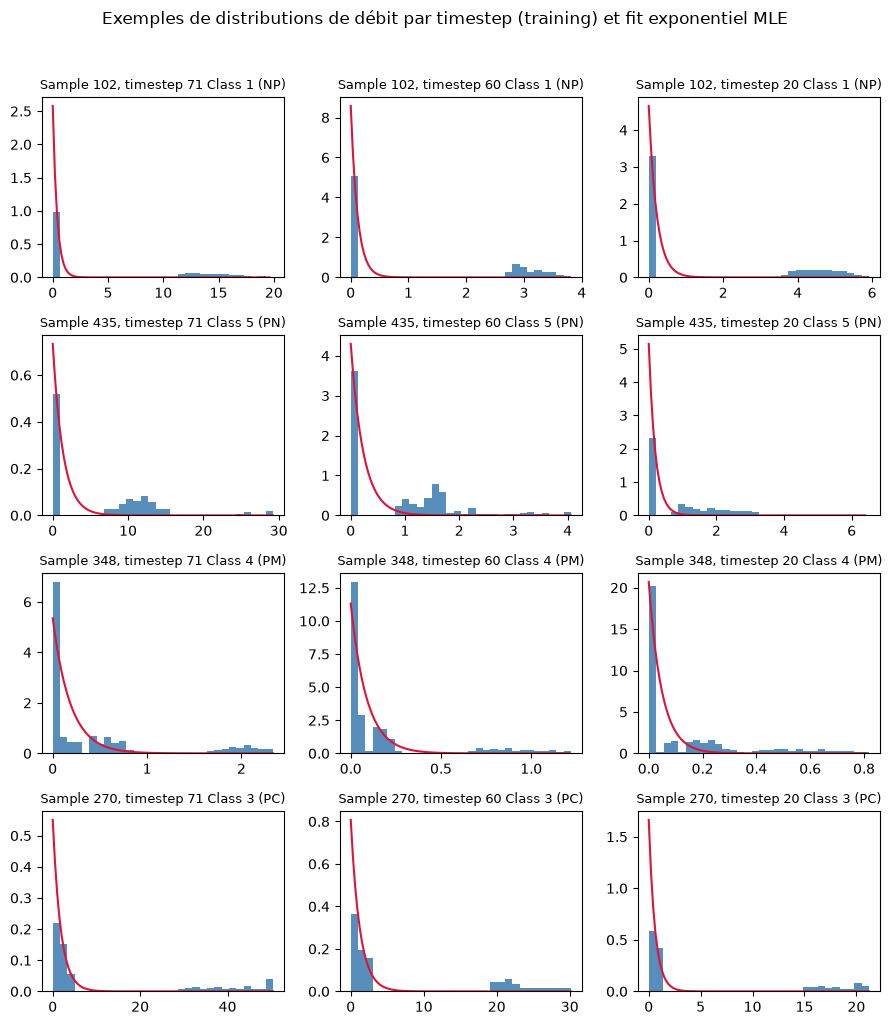

In [107]:
np.random.seed(SEED)
from data.preprocess import clean_series
idx_samples = np.random.randint(0, len(X_train), size=4)
idx_timesteps = np.random.randint(0, len(X_train[0]), size=3)
f,ax = plt.subplots(len(idx_samples), len(idx_timesteps), figsize=(3*len(idx_timesteps), 2.5*len(idx_samples)))
for i in idx_samples:
    for j in idx_timesteps:
        ax[idx_samples.tolist().index(i), idx_timesteps.tolist().index(j)].hist(X_train[i][j], bins=30, color="steelblue", alpha=0.9, density=True)
        ax[idx_samples.tolist().index(i), idx_timesteps.tolist().index(j)].set_title(f"Sample {i}, timestep {j} Class {y_train[i]} ({class_names.get(y_train[i], y_train[i])})", fontsize=9)
        ax[idx_samples.tolist().index(i), idx_timesteps.tolist().index(j)].plot(np.linspace(0, np.nanquantile(clean_series(X_train[i][j], threshold=-1.0), 0.999),100), dist.pdf(np.linspace(0, np.nanquantile(clean_series(X_train[i][j], threshold=-1.0), 0.999),100), train_params[i][j]), color="crimson", linewidth=1.5, label="MLE fit")
plt.suptitle("Exemples de distributions de débit par timestep (training) et fit exponentiel MLE", y=1.02)
plt.tight_layout()
plt.show()


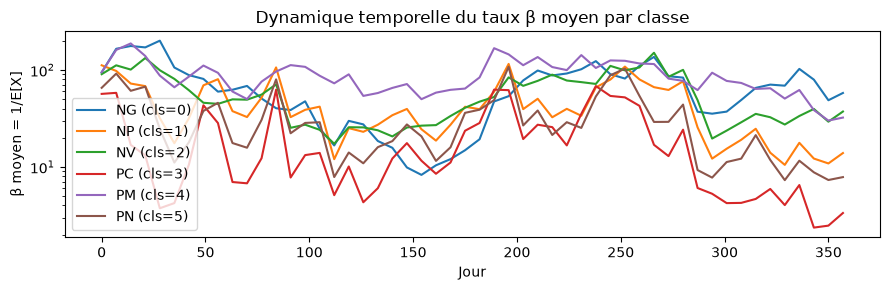

In [7]:
# β moyen par classe au cours du temps (dynamique temporelle)
fig, ax = plt.subplots(figsize=(9, 3))
t = np.arange(T) * AGGREGATE_DAYS
for cls in classes:
    idx = [i for i, l in enumerate(y_train) if l == cls]
    cls_params = np.stack([train_params[i] for i in idx])  # (N_cls, T, 1)
    mean_beta  = np.nanmean(cls_params[:, :, 0], axis=0)   # (T,)
    ax.semilogy(t, mean_beta, label=f"{class_names.get(cls, cls)} (cls={cls})")

ax.set_xlabel("Jour")
ax.set_ylabel("β moyen = 1/E[X]")
ax.set_title("Dynamique temporelle du taux β moyen par classe")
ax.legend()
plt.tight_layout()
plt.show()

---
## 3. Méthode eucl_params — Barycentre Euclidien sur β

**Représentation** : paramètres MLE `(T, 1)` — taux β direct.  
**Coût local** : SqEuclidean `||β_z - β_y||²` — pas de contrainte de positivité.  
**Barycentre** : minimise `Σᵢ D_γ(z, βᵢ)` en espace β — équivalent à une moyenne temporelle alignée.  
**Retour** : clippé à [1e-8, ∞) pour garantir β > 0.

In [112]:
# ── Hyperparamètres communs pour les 3 méthodes ───────────────────────────────
GAMMA   = 100
N_STEPS = 100
LR      = 0.01
PATIENCE = 20
VERBOSE = True
# ─────────────────────────────────────────────────────────────────────────────
# Visualisation des barycentres eucl_params vs données d'entraînement
t_axis = np.arange(T) * AGGREGATE_DAYS

In [113]:

sdtw_eucl_params = SoftDTW(SqEuclidean(), GAMMA, is_divergence=False, manual_grad=False)

print(f"SoftDTW eucl_params : γ={GAMMA}  n_steps={N_STEPS}  lr={LR}  patience={PATIENCE}")
print(f"Ajustement des barycentres pour {len(classes)} classes ...")

t0 = time.time()
bary_eucl_params = fit_barycenters(
    train_params, y_train, sdtw_eucl_params,
    n_steps=N_STEPS, lr=LR, patience=PATIENCE,
    verbose=True,
    n_jobs=-1
)
print(f"Terminé en {time.time()-t0:.1f}s")


SoftDTW eucl_params : γ=100  n_steps=100  lr=0.01  patience=20
Ajustement des barycentres pour 6 classes ...
Fitting barycenters for 6 classes: [0, 1, 2, 3, 4, 5] with 100 steps, lr=0.01, patience=20, min_rel_improve=0.0001
Fitting barycenter of 75 series with 100 steps, lr=0.01, patience=20, min_rel_improve=0.0001
Fitting barycenter of 75 series with 100 steps, lr=0.01, patience=20, min_rel_improve=0.0001
Fitting barycenter of 75 series with 100 steps, lr=0.01, patience=20, min_rel_improve=0.0001
  step    1/100  loss=298083.541598
  step    1/100  loss=175134.008556
  step    1/100  loss=349490.591875
  step   11/100  loss=271688.083941
  step   11/100  loss=129903.237946
  step   11/100  loss=328393.573603
  step   21/100  loss=263225.124074
  step   21/100  loss=118857.309648
  step   21/100  loss=318055.303331
Fitting barycenter of 75 series with 100 steps, lr=0.01, patience=20, min_rel_improve=0.0001
  step   31/100  loss=259901.183716
  step   31/100  loss=312970.534181
  step  

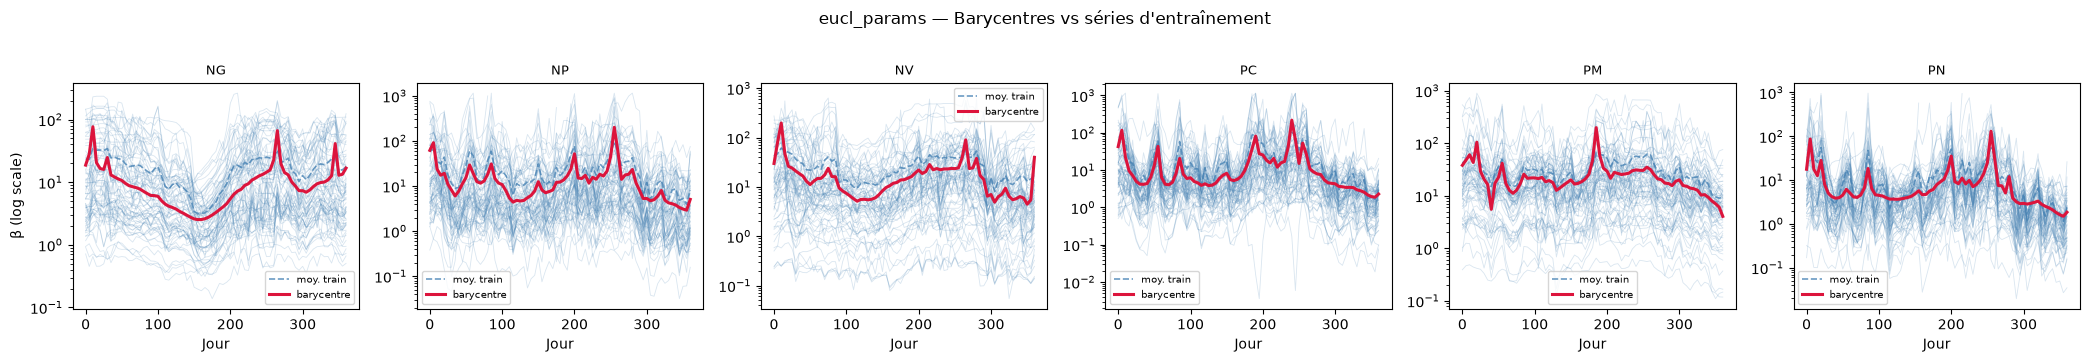

In [114]:


if len(np.unique(y_train)) == 1:
    fig, ax = plt.subplots(figsize=(7.5, 3.5))
    cls = np.unique(y_train)[0]
    idx = [i for i, l in enumerate(y_train) if l == cls]
    for i in idx:
        #replace 1e-6 values by NaN for plotting
        train_params[i][train_params[i] < 1e-6] = np.nan
        ax.semilogy(t_axis, train_params[i][:, 0], color="steelblue", alpha=0.2, linewidth=0.6)
    mean_b = np.nanmean([train_params[i][:, 0] for i in idx], axis=0)
    ax.semilogy(t_axis, mean_b, color="steelblue", linewidth=1.2, linestyle="--",
                label="moy. train", alpha=0.8)
    b = bary_eucl_params[cls][:, 0]
    ax.semilogy(t_axis, b, color="crimson", linewidth=2.2, label="barycentre")
    ax.set_title(f"{class_names.get(cls, cls)}", fontsize=9)
    ax.set_xlabel("Jour")
    ax.set_ylabel("β (log scale)")
    ax.legend(fontsize=7)
    plt.suptitle("eucl_params — Barycentres vs séries d'entraînement", y=1.02)
    plt.tight_layout()
    plt.show()

else:
    fig, axes = plt.subplots(1, len(np.unique(y_train)), figsize=(3.5 * len(np.unique(y_train)), 3.5))
    for ax, cls in zip(axes, np.unique(y_train)):
        idx = [i for i, l in enumerate(y_train) if l == cls]
        for i in idx:
            ax.semilogy(t_axis, train_params[i][:, 0], color="steelblue", alpha=0.2, linewidth=0.6)
            # ax.semilogy(t_axis, train_params[i], color="steelblue", alpha=0.2, linewidth=0.6)

        mean_b = np.nanmean([train_params[i][:, 0] for i in idx], axis=0)
        # mean_b = np.nanmean([train_params[i] for i in idx], axis=0)

        ax.semilogy(t_axis, mean_b, color="steelblue", linewidth=1.2, linestyle="--",
                    label="moy. train", alpha=0.8)
        b = bary_eucl_params[cls][:, 0]
        ax.semilogy(t_axis, b, color="crimson", linewidth=2.2, label="barycentre")
        ax.set_title(f"{class_names.get(cls, cls)}", fontsize=9)
        ax.set_xlabel("Jour")
        ax.legend(fontsize=7)

    axes[0].set_ylabel("β (log scale)")
    plt.suptitle("eucl_params — Barycentres vs séries d'entraînement", y=1.02)
    plt.tight_layout()
plt.show()

[0, 1, 2, 3, 4, 5]
eucl_params/bary — F1=0.187  Acc=0.233


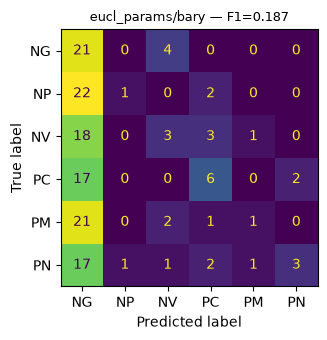

In [115]:
# Prédiction et évaluation
preds_eucl_params = predict2(test_params, bary_eucl_params, SqEuclidean(), GAMMA)

f1_ep = f1_score(y_test, preds_eucl_params, average="weighted", zero_division=0)
acc_ep = accuracy_score(y_test, preds_eucl_params)
print(f"eucl_params/bary — F1={f1_ep:.3f}  Acc={acc_ep:.3f}")

regime_labels = [class_names.get(c, str(c)) for c in classes]
cm = confusion_matrix(y_test, preds_eucl_params, labels=classes)
fig, ax = plt.subplots(figsize=(4, 3.5))
ConfusionMatrixDisplay(cm, display_labels=regime_labels).plot(ax=ax, colorbar=False)
ax.set_title(f"eucl_params/bary — F1={f1_ep:.3f}", fontsize=9)
plt.tight_layout()
plt.show()

---
## 4. Méthode wasps — Barycentre avec coût Wasserstein W₂²

**Représentation** : paramètres MLE `(T, 1)` — taux β.  
**Coût local** : W₂²(β₁, β₂) = 2·(1/β₁ − 1/β₂)² (distance Wasserstein entre lois expo.).  
**Contrainte** : `use_positivity_constraint=True` → optimisation en espace θ = softplus⁻¹(β).  
Le barycentre retourné est `softplus(θ*)` (toujours > 0).  

> **Note** : limitation structurelle — le barycentre Fréchet WaSPS en métrique W₂²  
> correspond à la **moyenne harmonique** des β (= moyenne arithmétique de 1/β = moyenne des μ).  
> Une station à très fort débit (β≈0.002, μ≈500 m³/s) peut dominer.

In [116]:
# Deux instances WaSPS : une pour le barycentre (avec contrainte), une pour predict
wasps_bary = WaSPS("exponential", use_positivity_constraint=True,log_correction=True)
sdtw_wasps = SoftDTW(wasps_bary, GAMMA, is_divergence=True, manual_grad=True)

print(f"SoftDTW wasps : γ={GAMMA}  n_steps={N_STEPS}  lr={LR}  patience={PATIENCE}")

SoftDTW wasps : γ=100  n_steps=100  lr=0.01  patience=20


In [ ]:
# Fit des barycentres wasps
print("Ajustement des barycentres wasps ...")
t0 = time.time()
bary_wasps = fit_barycenters(
    train_params, y_train, sdtw_wasps,
    n_steps=N_STEPS, lr=LR, patience=PATIENCE,verbose=VERBOSE, n_jobs=-1
)
print(f"Terminé en {time.time()-t0:.1f}s")


Ajustement des barycentres wasps ...
Fitting barycenters for 6 classes: [0, 1, 2, 3, 4, 5] with 100 steps, lr=0.01, patience=20, min_rel_improve=0.0001
Fitting barycenter of 75 series with 100 steps, lr=0.01, patience=20, min_rel_improve=0.0001
Fitting barycenter of 75 series with 100 steps, lr=0.01, patience=20, min_rel_improve=0.0001
Fitting barycenter of 75 series with 100 steps, lr=0.01, patience=20, min_rel_improve=0.0001
Fitting barycenter of 75 series with 100 steps, lr=0.01, patience=20, min_rel_improve=0.0001
  step    1/100  loss=297.226433
  step    1/100  loss=75.743503
  step    1/100  loss=386.285762
  step    1/100  loss=3518.780545
  step   11/100  loss=75.695914
  step   11/100  loss=386.282820
  step   11/100  loss=297.177040
  step   11/100  loss=3513.757463
  step   21/100  loss=75.647179
  step   21/100  loss=297.126250
  step   21/100  loss=386.279872
  early stop at step 21 (no improve for 20 steps)
  step   21/100  loss=3498.538405
Fitting barycenter of 75 serie

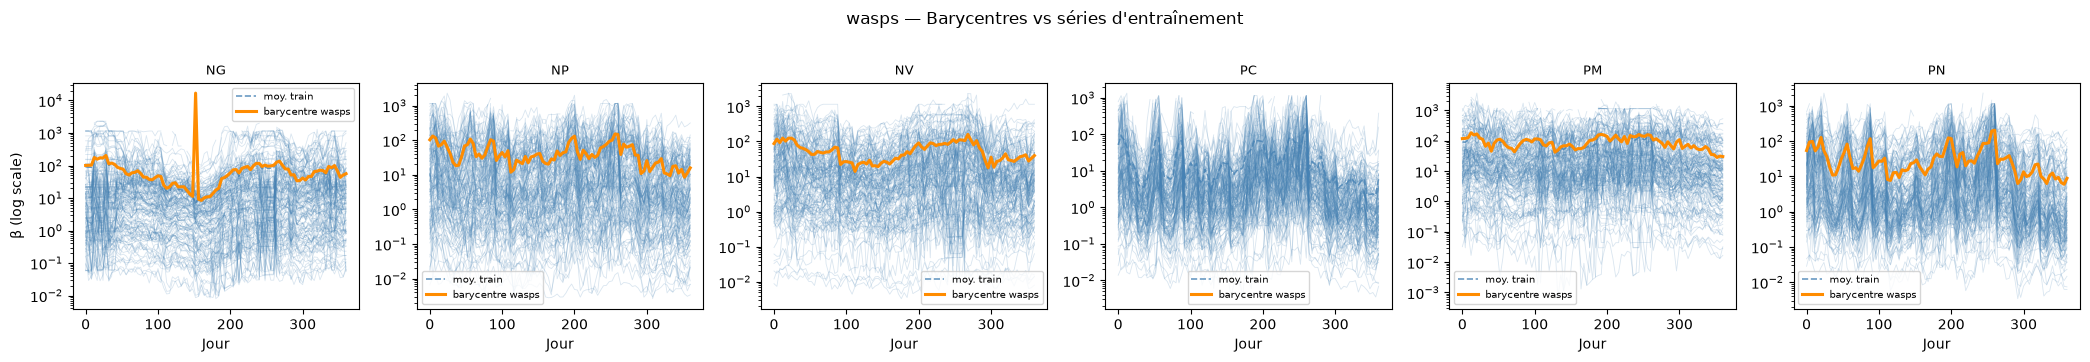

In [103]:
# Visualisation des barycentres wasps
if len(np.unique(y_train)) == 1:
    fig, ax = plt.subplots(figsize=(7.5, 3.5))
    cls = np.unique(y_train)[0]
    idx = [i for i, l in enumerate(y_train) if l == cls]
    for i in idx:
        ax.semilogy(t_axis, train_params[i][:, 0], color="steelblue", alpha=0.2, linewidth=0.6)
    mean_b = np.nanmean([train_params[i][:, 0] for i in idx], axis=0)
    ax.semilogy(t_axis, mean_b, "--", color="steelblue", linewidth=1.2, alpha=0.8, label="moy. train")
    b = bary_wasps[cls][:, 0]
    ax.semilogy(t_axis, b, color="darkorange", linewidth=2.2, label="barycentre wasps")
    ax.set_title(f"{class_names.get(cls, cls)}", fontsize=9)
    ax.set_xlabel("Jour")
    ax.set_ylabel("β (log scale)")
    ax.legend(fontsize=7)
    plt.suptitle("wasps — Barycentres vs séries d'entraînement", y=1.02)
    plt.tight_layout()
    plt.show()

else:

    fig, axes = plt.subplots(1, len(classes), figsize=(3.5 * len(classes), 3.5))
    for ax, cls in zip(axes, classes):
        idx = [i for i, l in enumerate(y_train) if l == cls]
        for i in idx:
            ax.semilogy(t_axis, train_params[i][:, 0], color="steelblue", alpha=0.2, linewidth=0.6)
        mean_b = np.nanmean([train_params[i][:, 0] for i in idx], axis=0)
        ax.semilogy(t_axis, mean_b, "--", color="steelblue", linewidth=1.2, alpha=0.8, label="moy. train")
        b = bary_wasps[cls][:, 0]
        ax.semilogy(t_axis, b, color="darkorange", linewidth=2.2, label="barycentre wasps")
        ax.set_title(f"{class_names.get(cls, cls)}", fontsize=9)
        ax.set_xlabel("Jour")
        ax.legend(fontsize=7)

    axes[0].set_ylabel("β (log scale)")
plt.suptitle("wasps — Barycentres vs séries d'entraînement", y=1.02)
plt.tight_layout()
plt.show()

In [78]:
import jax.numpy as jnp
def predict2(
    test_series: list,
    barycenters: dict,
    cost_fn,
    gamma: float,
) -> np.ndarray:
    """Classify each test series by minimum SoftDTW divergence to class barycenters.

    Args:
        test_series:  List of (T, p) arrays.
        barycenters:  dict label → (T, p) array (from fit_barycenters).
        cost_fn:      Ground cost callable(a, b) → scalar (positive-param space).
        gamma:        SoftDTW regularisation.

    Returns:
        predictions: (N_test,) array of class labels.
    """
    classes = sorted(barycenters.keys())
    bary_jax = {cls: jnp.array(barycenters[cls]) for cls in classes}
    print(classes)
    # Plain SDTW (not divergence): avoids self-term ½SDTW(b,b) dominating when
    # T_test ≠ T_bary, and matches KNN semantics (nearest centroid by DTW distance).
    sdtw_fn = SoftDTW(cost_fn, gamma, is_divergence=True, manual_grad=True)

    @jax.jit
    def divergence_to_bary(z: jax.Array, b: jax.Array) -> jax.Array:
        return sdtw_fn.value(z, b)

    preds = []
    for s in test_series:
        z = jnp.array(s)
        dists = [float(divergence_to_bary(z, bary_jax[cls])) for cls in classes]
        preds.append(classes[int(np.argmin(dists))])
    return np.array(preds)


[0, 1, 2, 3, 4, 5]
wasps/bary — F1=0.318  Acc=0.360


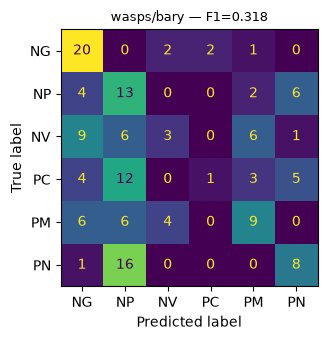

In [93]:
# Prédiction wasps
wasps_pred = WaSPS("exponential",  log_correction=True, use_positivity_constraint=False)
preds_wasps = predict2(test_params, bary_wasps, wasps_pred, GAMMA)

f1_w = f1_score(y_test, preds_wasps, average="weighted", zero_division=0)
acc_w = accuracy_score(y_test, preds_wasps)
print(f"wasps/bary — F1={f1_w:.3f}  Acc={acc_w:.3f}")

cm = confusion_matrix(y_test, preds_wasps, labels=classes)
fig, ax = plt.subplots(figsize=(4, 3.5))
regime_labels = [class_names.get(c, str(c)) for c in classes]
ConfusionMatrixDisplay(cm, display_labels=regime_labels).plot(ax=ax, colorbar=False)
ax.set_title(f"wasps/bary — F1={f1_w:.3f}", fontsize=9)
plt.tight_layout()
plt.show()

---
## 4bis. Méthode STA — Barycentre avec coût OT Sinkhorn

**Représentation** : données brutes `(T_sta, N_samples)` — valeurs de débit directement.  
**Coût local** : OT régularisé (Sinkhorn) entre distributions empiriques par timestep.  
**Barycentre** : minimise Σᵢ D_γ(z, xᵢ) via autodiff *through* Sinkhorn (OTT-JAX).  

> **Complexité** : T²_sta appels Sinkhorn/step — intractable pour T=365.  
> On tronque à `T_STA ≤ 25` timesteps, cohérent avec `configs/river_sta.yaml`.


In [39]:
import sys
sys.path.insert(0, str(_SRC))
from baselines.sta_wrapper import make_cost_fn, sta_distance

# T²_sta appels Sinkhorn par step : T_STA=8 → 64 OT/step × 90 séries (tractable)
# Augmenter jusqu'à 25 pour des résultats comparables à river_sta.yaml (plus lent)
T_STA       = 1
EPS_STA     = 0.05
N_STEPS_STA = 100

X_train_sta = [s[::T_STA] for s in X_train]
X_test_sta  = [s[::T_STA] for s in X_test]

# drop nan
X_train_sta = [np.nan_to_num(s, nan=0.0) for s in X_train_sta]
X_test_sta  = [np.nan_to_num(s, nan=0.0) for s in X_test_sta]
# down sample the number of sample and not timestep

cost_sta = make_cost_fn(EPS_STA)
sdtw_sta = SoftDTW(cost_sta, GAMMA, is_divergence=True, manual_grad=False)

t_axis_sta = np.arange(len(X_train_sta[0]))
# t_axis_sta = t_axis_sta[::2]
# (T_STA) * AGGREGATE_DAYS
print(f"SoftDTW STA : gamma={GAMMA}  T_sta={T_STA}  eps={EPS_STA}  n_steps={N_STEPS_STA}")
print(f"Forme d'une série downsampled : {X_train_sta[0].shape}  (T={len(X_train_sta[0])}, D={X_train_sta[0].shape[1]})")


SoftDTW STA : gamma=10  T_sta=1  eps=0.05  n_steps=100
Forme d'une série downsampled : (52, 70)  (T=52, D=70)


In [23]:
# Fit des barycentres STA
print("Ajustement des barycentres STA ...")
t0 = time.time()
bary_sta = fit_barycenters(
    X_train_sta, y_train, sdtw_sta,
    n_steps=N_STEPS_STA, lr=LR, patience=PATIENCE, verbose=VERBOSE,
    n_jobs=4
)
print(f"Terminé en {time.time()-t0:.1f}s")

Ajustement des barycentres STA ...
Fitting barycenters for 4 classes: [0, 1, 3, 5] with 100 steps, lr=0.25, patience=20, min_rel_improve=0.0001
Fitting barycenter of 10 series with 100 steps, lr=0.25, patience=20, min_rel_improve=0.0001
Fitting barycenter of 10 series with 100 steps, lr=0.25, patience=20, min_rel_improve=0.0001
Fitting barycenter of 10 series with 100 steps, lr=0.25, patience=20, min_rel_improve=0.0001
Fitting barycenter of 10 series with 100 steps, lr=0.25, patience=20, min_rel_improve=0.0001
  step    1/100  loss=197.996897
  step    1/100  loss=1147.352000
  step    1/100  loss=552.429047
  step    1/100  loss=4669.365218
  step   11/100  loss=529.743582
  step   11/100  loss=193.749996
  step   11/100  loss=952.611412
  step   11/100  loss=4374.918377
  step   21/100  loss=189.929217
  step   21/100  loss=4164.207138
  step   21/100  loss=843.049060
  step   21/100  loss=508.534310
  step   31/100  loss=186.499414
  step   31/100  loss=489.750864
  step   31/100  l

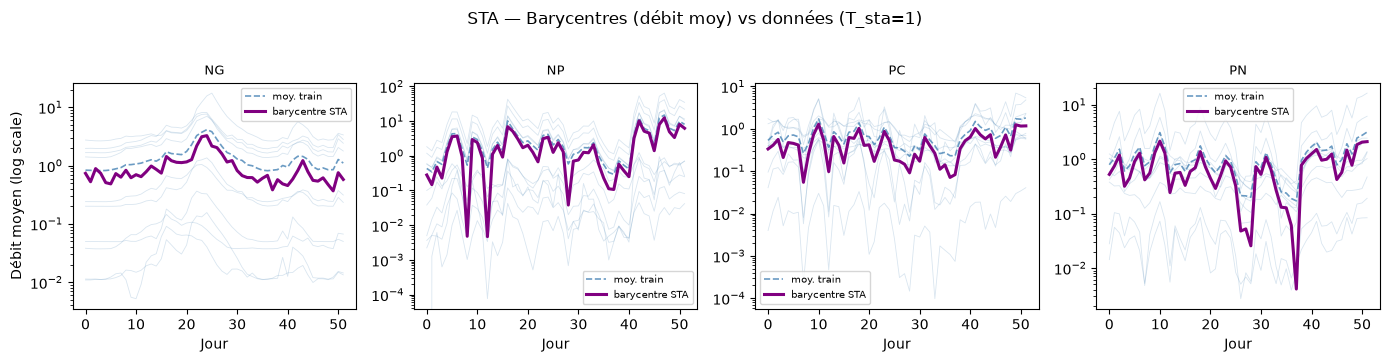

In [24]:
# Visualisation des barycentres STA — débit moyen du barycentre vs séries train
if len(np.unique(y_train)) == 1:
    fig, ax = plt.subplots(figsize=(7.5, 3.5))
    cls = np.unique(y_train)[0]
    idx = [i for i, l in enumerate(y_train) if l == cls]
    for i in idx:
        ax.semilogy(t_axis_sta, np.nanmean(X_train_sta[i], axis=1),
                    color="steelblue", alpha=0.2, linewidth=0.6)
    mean_raw = np.nanmean([np.nanmean(X_train_sta[i], axis=1) for i in idx], axis=0)
    ax.semilogy(t_axis_sta, mean_raw, "--", color="steelblue", linewidth=1.2,
                alpha=0.8, label="moy. train")
    b_mean = np.nanmean(bary_sta[cls], axis=1)
    ax.semilogy(t_axis_sta, b_mean, color="purple", linewidth=2.2,
                label="barycentre STA")
    ax.set_title(f"{class_names.get(cls, cls)}", fontsize=9)
    ax.set_xlabel("Jour")
    ax.set_ylabel("Débit moyen (log scale)")
    ax.legend(fontsize=7)
    plt.suptitle(f"STA — Barycentres (débit moy) vs données (T_sta={T_STA})", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    fig, axes = plt.subplots(1, len(classes), figsize=(3.5 * len(classes), 3.5))
    for ax, cls in zip(axes, classes):
        idx = [i for i, l in enumerate(y_train) if l == cls]
        for i in idx:
            ax.semilogy(t_axis_sta, np.nanmean(X_train_sta[i], axis=1),
                        color="steelblue", alpha=0.2, linewidth=0.6)
        mean_raw = np.nanmean([np.nanmean(X_train_sta[i], axis=1) for i in idx], axis=0)
        ax.semilogy(t_axis_sta, mean_raw, "--", color="steelblue", linewidth=1.2,
                    alpha=0.8, label="moy. train")
        b_mean = np.nanmean(bary_sta[cls], axis=1)
        ax.semilogy(t_axis_sta, b_mean, color="purple", linewidth=2.2,
                    label="barycentre STA")
        ax.set_title(f"{class_names.get(cls, cls)}", fontsize=9)
        ax.set_xlabel("Jour")
        ax.legend(fontsize=7)

    axes[0].set_ylabel("Débit moyen (log scale)")
    plt.suptitle(f"STA — Barycentres (débit moy) vs données (T_sta={T_STA})", y=1.02)
    plt.tight_layout()
    plt.show()


In [25]:
bary_sta = np.load("bary_sta.npz", allow_pickle=True)['bary'] 
t_axis_sta= np.load("bary_sta.npz", allow_pickle=True)['t_axis']
T_STA= np.load("bary_sta.npz", allow_pickle=True)['T_STA']
EPS_STA= np.load("bary_sta.npz", allow_pickle=True)['eps']
GAMMA = np.load("bary_sta.npz", allow_pickle=True)['gamma']

In [42]:
bary_sta.item()[5], np.array(X_test_sta).shape

(array([[0.42217774, 1.03829483, 0.14020443, ..., 0.05571379, 0.02683115,
         0.83471285],
        [0.07653635, 0.33773312, 0.06335516, ..., 0.22528841, 0.22785635,
         5.51739542],
        [1.88756716, 2.89820875, 0.21429943, ..., 0.07418356, 0.04257086,
         1.73558225],
        ...,
        [0.88583049, 1.60988502, 0.09795612, ..., 0.17224278, 0.14078889,
         6.52045289],
        [2.40848691, 3.04518958, 0.21719432, ..., 0.24825151, 0.23858831,
         5.95659715],
        [1.24263178, 2.57300345, 0.11590307, ..., 0.06217313, 0.03801386,
         3.24209469]], shape=(52, 70)),
 (100, 52, 70))

Prédiction STA (joblib parallèle) ...


 80%|████████  | 80/100 [05:07<01:38,  4.91s/it]/home/mgallet/Documents/Codes/Python/3_DEVELOPPEMENT/WaSPS-DTW/WaSPS-DTW/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
100%|██████████| 100/100 [08:09<00:00,  4.89s/it]


Terminé en 819.1s
STA/bary — F1=0.276  Acc=0.290  (T_sta=1)


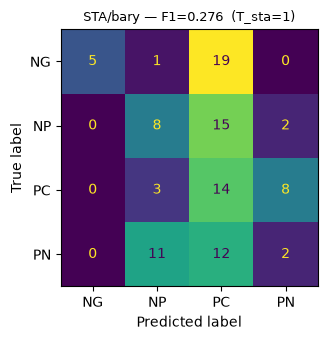

In [40]:
import jax.numpy as jnp
from joblib import Parallel, delayed


def predict2(
    test_series: list,
    barycenters: dict,
    cost_fn,
    gamma: float,
) -> np.ndarray:
    """Nearest-barycenter classifier (WaSPS/eucl_params)."""
    classes = sorted(barycenters.keys())
    bary_jax = {cls: jnp.array(barycenters[cls]) for cls in classes}
    sdtw_fn = SoftDTW(cost_fn, gamma, is_divergence=True, manual_grad=True)

    @jax.jit
    def dist_to_bary(z: jax.Array, b: jax.Array) -> jax.Array:
        return sdtw_fn.value(z, b)

    preds = []
    for s in test_series:
        z = jnp.array(s)
        dists = [float(dist_to_bary(z, bary_jax[cls])) for cls in classes]
        preds.append(classes[int(np.argmin(dists))])
    return np.array(preds)


# ── Prédiction STA ──────────────────────────────────────────────────────────

def _sta_predict_one(s, bary_sta, classes, gamma, epsilon):
    """Worker : distances STA d'une série test à chaque barycentre de classe."""
    from baselines.sta_wrapper import sta_distance as _sta_dist
    dists = [_sta_dist(s, bary_sta[cls], gamma=gamma, epsilon=epsilon)
             for cls in classes]
    return classes[int(np.argmin(dists))]

import tqdm
def predict_sta(
    test_series: list,
    bary_sta: dict,
    classes: list,
    gamma: float,
    epsilon: float,
    n_jobs: int = -1,
) -> np.ndarray:
    """Nearest-barycenter STA : parallélisé sur les séries test (loky).

    Chaque worker recompile _sinkhorn_jit une fois et traite un sous-ensemble
    de séries test indépendantes.
    """
    results = Parallel(n_jobs=n_jobs, backend='loky')(
        delayed(_sta_predict_one)(s, bary_sta, classes, gamma, epsilon)
        for s in 
        tqdm.tqdm(test_series)
    )
    return np.array(results)


print("Prédiction STA (joblib parallèle) ...")
t0 = time.time()
preds_sta = predict_sta(X_test_sta, bary_sta.item(), classes, GAMMA, EPS_STA, n_jobs=-1)
print(f"Terminé en {time.time()-t0:.1f}s")

f1_sta  = f1_score(y_test, preds_sta, average='weighted', zero_division=0)
acc_sta = accuracy_score(y_test, preds_sta)
print(f"STA/bary — F1={f1_sta:.3f}  Acc={acc_sta:.3f}  (T_sta={T_STA})")

cm = confusion_matrix(y_test, preds_sta, labels=classes)
fig, ax = plt.subplots(figsize=(4, 3.5))
regime_labels = [class_names.get(c, str(c)) for c in classes]
ConfusionMatrixDisplay(cm, display_labels=regime_labels).plot(ax=ax, colorbar=False)
ax.set_title(f"STA/bary — F1={f1_sta:.3f}  (T_sta={T_STA})", fontsize=9)
plt.tight_layout()
plt.show()


In [44]:
preds_sta,y_test,classes

(array([0, 3, 3, 3, 3, 0, 3, 0, 3, 3, 3, 1, 3, 3, 3, 3, 0, 3, 3, 3, 0, 3,
        3, 3, 3, 3, 5, 3, 3, 3, 3, 3, 3, 3, 3, 1, 3, 1, 1, 5, 3, 3, 1, 1,
        1, 3, 1, 3, 1, 3, 3, 5, 5, 3, 5, 3, 3, 3, 3, 5, 3, 3, 5, 5, 1, 3,
        5, 1, 3, 5, 3, 3, 1, 3, 3, 3, 5, 3, 1, 3, 3, 1, 1, 1, 1, 1, 3, 1,
        3, 1, 3, 5, 3, 3, 1, 3, 3, 1, 1, 3]),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
        5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]),
 [0, 1, 3, 5])

---
## 5. Méthode eucl_raw — Barycentre sur les données brutes

**Représentation** : données brutes `(T, 200)` — valeurs de débit directement.  
**Coût local** : SqEuclidean sur les vecteurs de 200 valeurs — pas d'estimation paramétrique.  
**Barycentre** : moyenne temporelle alignée des distributions empiriques.  
Pas de contrainte de positivité, mais les données brutes sont déjà toutes > 0.

In [ ]:
sdtw_eucl_raw = SoftDTW(SqEuclidean(), GAMMA, is_divergence=True, manual_grad=False)

print("Ajustement des barycentres eucl_raw ...")
t0 = time.time()
bary_eucl_raw = fit_barycenters(
    X_train, y_train, sdtw_eucl_raw,
    n_steps=N_STEPS, lr=LR, patience=PATIENCE,
)
print(f"Terminé en {time.time()-t0:.1f}s")

for cls in classes:
    b = bary_eucl_raw[cls]
    print(f"  cls {cls} ({class_names.get(cls,'?'):4s}) : shape={b.shape}  "
          f"nan={np.isnan(b).sum()}  min={b.min():.4g}  max={b.max():.4g}")

In [ ]:
# Visualisation des barycentres eucl_raw — on affiche le débit moyen du barycentre
fig, axes = plt.subplots(1, len(classes), figsize=(3.5 * len(classes), 3.5))
for ax, cls in zip(axes, classes):
    idx = [i for i, l in enumerate(y_train) if l == cls]
    # Débit moyen par timestep pour les séries train
    for i in idx:
        ax.semilogy(t_axis, np.nanmean(X_train[i], axis=1), color="steelblue",
                    alpha=0.2, linewidth=0.6)
    mean_raw = np.nanmean([np.nanmean(X_train[i], axis=1) for i in idx], axis=0)
    ax.semilogy(t_axis, mean_raw, "--", color="steelblue", linewidth=1.2, alpha=0.8,
                label="moy. train")
    b_mean = np.nanmean(bary_eucl_raw[cls], axis=1)  # débit moyen du barycentre
    ax.semilogy(t_axis, b_mean, color="forestgreen", linewidth=2.2, label="barycentre (débit moy)")
    ax.set_title(f"{class_names.get(cls, cls)}", fontsize=9)
    ax.set_xlabel("Jour")
    ax.legend(fontsize=7)

axes[0].set_ylabel("Débit moyen (log scale)")
plt.suptitle("eucl_raw — Barycentres (débit moyen) vs données", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Prédiction eucl_raw
preds_eucl_raw = predict(X_test, bary_eucl_raw, SqEuclidean(), GAMMA)

f1_er = f1_score(y_test, preds_eucl_raw, average="weighted", zero_division=0)
acc_er = accuracy_score(y_test, preds_eucl_raw)
print(f"eucl_raw/bary — F1={f1_er:.3f}  Acc={acc_er:.3f}")

cm = confusion_matrix(y_test, preds_eucl_raw, labels=classes)
fig, ax = plt.subplots(figsize=(4, 3.5))
ConfusionMatrixDisplay(cm, display_labels=regime_labels).plot(ax=ax, colorbar=False)
ax.set_title(f"eucl_raw/bary — F1={f1_er:.3f}", fontsize=9)
plt.tight_layout()
plt.show()

---
## 6. Comparaison des 4 méthodes


In [ ]:
# Tableau récapitulatif
results_summary = [
    ("eucl_params/bary", y_test, preds_eucl_params),
    ("wasps/bary",       y_test, preds_wasps),
    ("eucl_raw/bary",    y_test, preds_eucl_raw),
    (f"STA/bary (T={T_STA})", y_test, preds_sta),
]

print(f"{'Méthode':<24}  {'F1 (weighted)':>14}  {'Accuracy':>10}")
print("-" * 54)
for name, true, pred in results_summary:
    f1  = f1_score(true, pred, average="weighted", zero_division=0)
    acc = accuracy_score(true, pred)
    print(f"  {name:<24}  {f1:>14.3f}  {acc:>10.3f}")


In [ ]:
# Matrices de confusion côte à côte
fig, axes = plt.subplots(1, 4, figsize=(17, 4))
configs = [
    ("eucl_params/bary",      preds_eucl_params, "RdBu"),
    ("wasps/bary",            preds_wasps,       "PuOr"),
    ("eucl_raw/bary",         preds_eucl_raw,    "PRGn"),
    (f"STA/bary (T={T_STA})", preds_sta,         "BrBG"),
]
for ax, (name, pred, cmap) in zip(axes, configs):
    f1 = f1_score(y_test, pred, average="weighted", zero_division=0)
    cm = confusion_matrix(y_test, pred, labels=classes)
    ConfusionMatrixDisplay(cm, display_labels=regime_labels).plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(f"{name}\nF1={f1:.3f}", fontsize=9)
    ax.tick_params(labelsize=8)

plt.suptitle("Matrices de confusion — Classif. barycentre, agg=4, gamma=10", y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
# Superposition des barycentres des 3 méthodes pour chaque classe
fig, axes = plt.subplots(len(classes), 1, figsize=(10, 2.5 * len(classes)), sharex=True)

colors = {"eucl_params": "crimson", "wasps": "darkorange", "eucl_raw": "forestgreen"}

for ax, cls in zip(axes, classes):
    idx = [i for i, l in enumerate(y_train) if l == cls]
    # Fond : séries train (β)
    for i in idx:
        ax.semilogy(t_axis, train_params[i][:, 0], color="lightsteelblue", alpha=0.15, linewidth=0.5)
    mean_b = np.nanmean([train_params[i][:, 0] for i in idx], axis=0)
    ax.semilogy(t_axis, mean_b, "--", color="steelblue", linewidth=1.2, alpha=0.6, label="moy. train")
    # Barycentres
    ax.semilogy(t_axis, bary_eucl_params[cls][:, 0], color=colors["eucl_params"],
                linewidth=2, label="eucl_params")
    ax.semilogy(t_axis, bary_wasps[cls][:, 0], color=colors["wasps"],
                linewidth=2, label="wasps")
    # eucl_raw : on convertit en β via estimation
    bary_raw_params = dist.fit_time_series(
        clean_time_series(bary_eucl_raw[cls]), dtype=np.float64
    )
    if bary_raw_params is not None and not np.all(np.isnan(bary_raw_params)):
        ax.semilogy(t_axis, bary_raw_params[:, 0], color=colors["eucl_raw"],
                    linewidth=2, label="eucl_raw (β re-estimé)")
    ax.set_ylabel(f"{class_names.get(cls, cls)} β")
    ax.legend(fontsize=7, loc="upper right", ncol=4)

axes[-1].set_xlabel("Jour")
plt.suptitle("Comparaison des barycentres — 3 méthodes × 4 classes", y=1.01)
plt.tight_layout()
plt.show()

---
## 7. Exploration interactive

### 7a. Effet de γ sur la qualité de la classification

In [ ]:
# Balayage γ — eucl_params et wasps uniquement (eucl_raw plus lent car dim=200)
GAMMAS_SWEEP = [0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0]
f1_eucl_sweep, f1_wasps_sweep = [], []

print(f"  {'γ':>6}  {'eucl_params':>12}  {'wasps':>8}")
print("-" * 32)
for g in GAMMAS_SWEEP:
    # eucl_params
    sdtw_e = SoftDTW(SqEuclidean(), g, is_divergence=True, manual_grad=False)
    b_e = fit_barycenters(train_params, y_train, sdtw_e, n_steps=N_STEPS, lr=LR, patience=PATIENCE)
    p_e = predict(test_params, b_e, SqEuclidean(), g)
    f1_e = f1_score(y_test, p_e, average="weighted", zero_division=0)
    f1_eucl_sweep.append(f1_e)
    # wasps
    sdtw_w = SoftDTW(WaSPS("exponential", use_positivity_constraint=True), g,
                     is_divergence=True, manual_grad=True)
    b_w = fit_barycenters(train_params, y_train, sdtw_w, n_steps=N_STEPS, lr=LR, patience=PATIENCE)
    p_w = predict(test_params, b_w, WaSPS("exponential", log_correction=True), g)
    f1_w = f1_score(y_test, p_w, average="weighted", zero_division=0)
    f1_wasps_sweep.append(f1_w)
    print(f"  {g:>6.1f}  {f1_e:>12.3f}  {f1_w:>8.3f}")

fig, ax = plt.subplots(figsize=(7, 3))
ax.semilogx(GAMMAS_SWEEP, f1_eucl_sweep, "o-", label="eucl_params/bary")
ax.semilogx(GAMMAS_SWEEP, f1_wasps_sweep, "s-", label="wasps/bary")
ax.axvline(GAMMA, color="gray", linestyle="--", linewidth=0.8, label=f"γ={GAMMA} (défaut)")
ax.set_xlabel("γ (régularisation Soft-DTW)")
ax.set_ylabel("F1 pondéré")
ax.set_title(f"Sensibilité à γ — River agg={AGGREGATE_DAYS}, barycentre")
ax.legend()
plt.tight_layout()
plt.show()

### 7b. Effet du nombre de pas d'optimisation

In [ ]:
# Convergence : F1 en fonction du nb de steps (eucl_params, classe par classe)
# On re-fit avec n_steps progressifs en désactivant l'early stop pour voir la courbe brute
STEPS_SWEEP = [10, 25, 50, 100, 200, 400]
f1_steps_eucl, f1_steps_wasps = [], []

sdtw_e = SoftDTW(SqEuclidean(), GAMMA, is_divergence=True, manual_grad=False)
sdtw_w = SoftDTW(WaSPS("exponential", use_positivity_constraint=True), GAMMA,
                 is_divergence=True, manual_grad=True)

print(f"  {'n_steps':>8}  {'eucl_params':>12}  {'wasps':>8}")
print("-" * 36)
for n in STEPS_SWEEP:
    b_e = fit_barycenters(train_params, y_train, sdtw_e, n_steps=n, lr=LR, patience=0)  # patience=0 = sans arrêt précoce
    p_e = predict(test_params, b_e, SqEuclidean(), GAMMA)
    f1_e = f1_score(y_test, p_e, average="weighted", zero_division=0)
    f1_steps_eucl.append(f1_e)
    b_w = fit_barycenters(train_params, y_train, sdtw_w, n_steps=n, lr=LR, patience=0)
    p_w = predict(test_params, b_w, WaSPS("exponential", log_correction=True), GAMMA)
    f1_w = f1_score(y_test, p_w, average="weighted", zero_division=0)
    f1_steps_wasps.append(f1_w)
    print(f"  {n:>8d}  {f1_e:>12.3f}  {f1_w:>8.3f}")

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(STEPS_SWEEP, f1_steps_eucl, "o-", label="eucl_params/bary")
ax.plot(STEPS_SWEEP, f1_steps_wasps, "s-", label="wasps/bary")
ax.set_xlabel("Nombre de pas d'optimisation (n_steps)")
ax.set_ylabel("F1 pondéré")
ax.set_title(f"Convergence — River agg={AGGREGATE_DAYS}, γ={GAMMA}")
ax.legend()
plt.tight_layout()
plt.show()

### 7c. Inspection détaillée d'un barycentre — fit pas-à-pas (1 classe)

In [ ]:
# Capturer la loss à chaque pas pour une classe donnée
import io, re
from contextlib import redirect_stdout

CLS_INSPECT = classes[0]   # ← modifier ici pour explorer une autre classe
METHOD_INSPECT = "eucl_params"  # "eucl_params" | "wasps"

idx_cls = [i for i, l in enumerate(y_train) if l == CLS_INSPECT]
series_cls = [train_params[i] for i in idx_cls]

if METHOD_INSPECT == "wasps":
    sdtw_inspect = SoftDTW(WaSPS("exponential", use_positivity_constraint=True),
                           GAMMA, is_divergence=True, manual_grad=True)
else:
    sdtw_inspect = SoftDTW(SqEuclidean(), GAMMA, is_divergence=True, manual_grad=False)

# Capturer les lignes verbose
buf = io.StringIO()
with redirect_stdout(buf):
    fit_barycenter(series_cls, sdtw_inspect,
                   n_steps=N_STEPS, lr=LR, patience=0, verbose=True)
lines = buf.getvalue().strip().split("\n")

steps_log, losses_log = [], []
for line in lines:
    m = re.search(r"step\s+(\d+)/\d+\s+loss=([\d.]+)", line)
    if m:
        steps_log.append(int(m.group(1)))
        losses_log.append(float(m.group(2)))

fig, ax = plt.subplots(figsize=(8, 3))
ax.semilogy(steps_log, losses_log, ".-")
ax.set_xlabel("Pas")
ax.set_ylabel("Loss (log)")
ax.set_title(f"Convergence barycentre — {METHOD_INSPECT}, classe {class_names.get(CLS_INSPECT, CLS_INSPECT)}, γ={GAMMA}")
plt.tight_layout()
plt.show()
print(f"Loss initiale : {losses_log[0]:.4f}  finale : {losses_log[-1]:.4f}  "
      f"ratio : {losses_log[-1]/losses_log[0]:.3f}")